# Research: LSTM Forecasting (Ex07)

## Contexte

Les reseaux LSTM (Long Short-Term Memory) sont la pierre angulaire du deep learning
pour les series temporelles. Inventes par Hochreiter & Schmidhuber (1997), ils resolvent
le probleme du gradient evanescent des RNN classiques grace a 3 portes :

- **Porte d'oubli** (forget gate): Quelle memoire discarder ?
- **Porte d'entree** (input gate): Quelle nouvelle information stocker ?
- **Porte de sortie** (output gate): Quelle partie de la memoire utiliser ?

## Performance attendue

- Strategie: nouvelle (pas encore de backtest QC Cloud)
- Objectif pedagogique: comprendre les equations LSTM sans framework ML
- Sharpe attendu: 0.2-0.4 (implementation simplifiee)

## Objectif de ce notebook

1. Visualiser le fonctionnement d'une cellule LSTM
2. Tester l'impact de chaque porte sur le signal
3. Simuler un backtest avec yfinance
4. Comparer avec un RNN simple pour montrer l'avantage LSTM

> **[DATA-ONLY]** Ce notebook est a visee exploratoire. L'implementation LSTM (cellule from scratch + backtest) produit une erreur ValueError sur l'evaluation de Series booleennes, bloquant la generation de signaux et le calcul de metriques. Le notebook presente l'architecture LSTM, les mecanismes de portes et la visualisation des filtres mais ne produit pas de backtest fonctionnel.

## 1. Setup et Donnees

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKER = 'SPY'
START = '2015-01-01'
END = '2026-01-01'

print("Chargement des donnees yfinance...")
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
prices = raw['Close'].dropna()
returns = prices.pct_change().dropna()
print(f"Periode: {prices.index[0].date()} -> {prices.index[-1].date()}")
print(f"Observations: {len(prices)} jours")

Chargement des donnees yfinance...


[*********************100%***********************]  1 of 1 completed

Periode: 2015-01-02 -> 2025-12-31
Observations: 2766 jours


## 2. Implementation pas-a-pas d'une cellule LSTM

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -10, 10)))

def lstm_cell(x_t, h_prev, c_prev, wf=0.5, wi=0.5, wo=0.5):
    """
    Cellule LSTM simplifiee.
    
    Equations:
    f_t = sigmoid(W_f . [h_{t-1}, x_t])  -- Porte d'oubli
    i_t = sigmoid(W_i . [h_{t-1}, x_t])  -- Porte d'entree
    c_tilde = tanh(W_c . [h_{t-1}, x_t]) -- Candidat memoire
    c_t = f_t * c_{t-1} + i_t * c_tilde   -- Mise a jour memoire
    o_t = sigmoid(W_o . [c_t])            -- Porte de sortie
    h_t = o_t * tanh(c_t)                 -- Etat cache
    """
    combined = np.concatenate([h_prev, x_t])
    
    # Porte d'oubli
    forget_gate = sigmoid(wf * np.sum(combined))
    
    # Porte d'entree
    input_gate = sigmoid(wi * np.sum(combined))
    
    # Candidat
    candidate = np.tanh(np.sum(combined) * 0.3)
    
    # Mise a jour memoire
    c_new = forget_gate * c_prev + input_gate * candidate
    
    # Porte de sortie
    output_gate = sigmoid(wo * np.sum(c_new))
    h_new = output_gate * np.tanh(c_new)
    
    return h_new, c_new, {'forget': forget_gate, 'input': input_gate, 'output': output_gate}

# Test sur une sequence
h = np.array([0.0])
c = np.array([0.0])

sequence = returns.iloc[:50].values.reshape(-1, 1)
hidden_states = []
cell_states = []
gates_history = {'forget': [], 'input': [], 'output': []}

for t in range(len(sequence)):
    h, c, gates = lstm_cell(sequence[t], h, c)
    hidden_states.append(h[0])
    cell_states.append(c[0])
    for k, v in gates.items():
        gates_history[k].append(v)

print("Cellule LSTM executee sur 50 jours de rendements SPY")
print(f"h_final: {h[0]:.4f}, c_final: {c[0]:.4f}")
print(f"Portes moyennes: forget={np.mean(gates_history['forget']):.3f}, "
      f"input={np.mean(gates_history['input']):.3f}, output={np.mean(gates_history['output']):.3f}")

Cellule LSTM executee sur 50 jours de rendements SPY
h_final: 0.0003, c_final: 0.0006
Portes moyennes: forget=0.500, input=0.500, output=0.500


## 3. Visualisation des portes LSTM

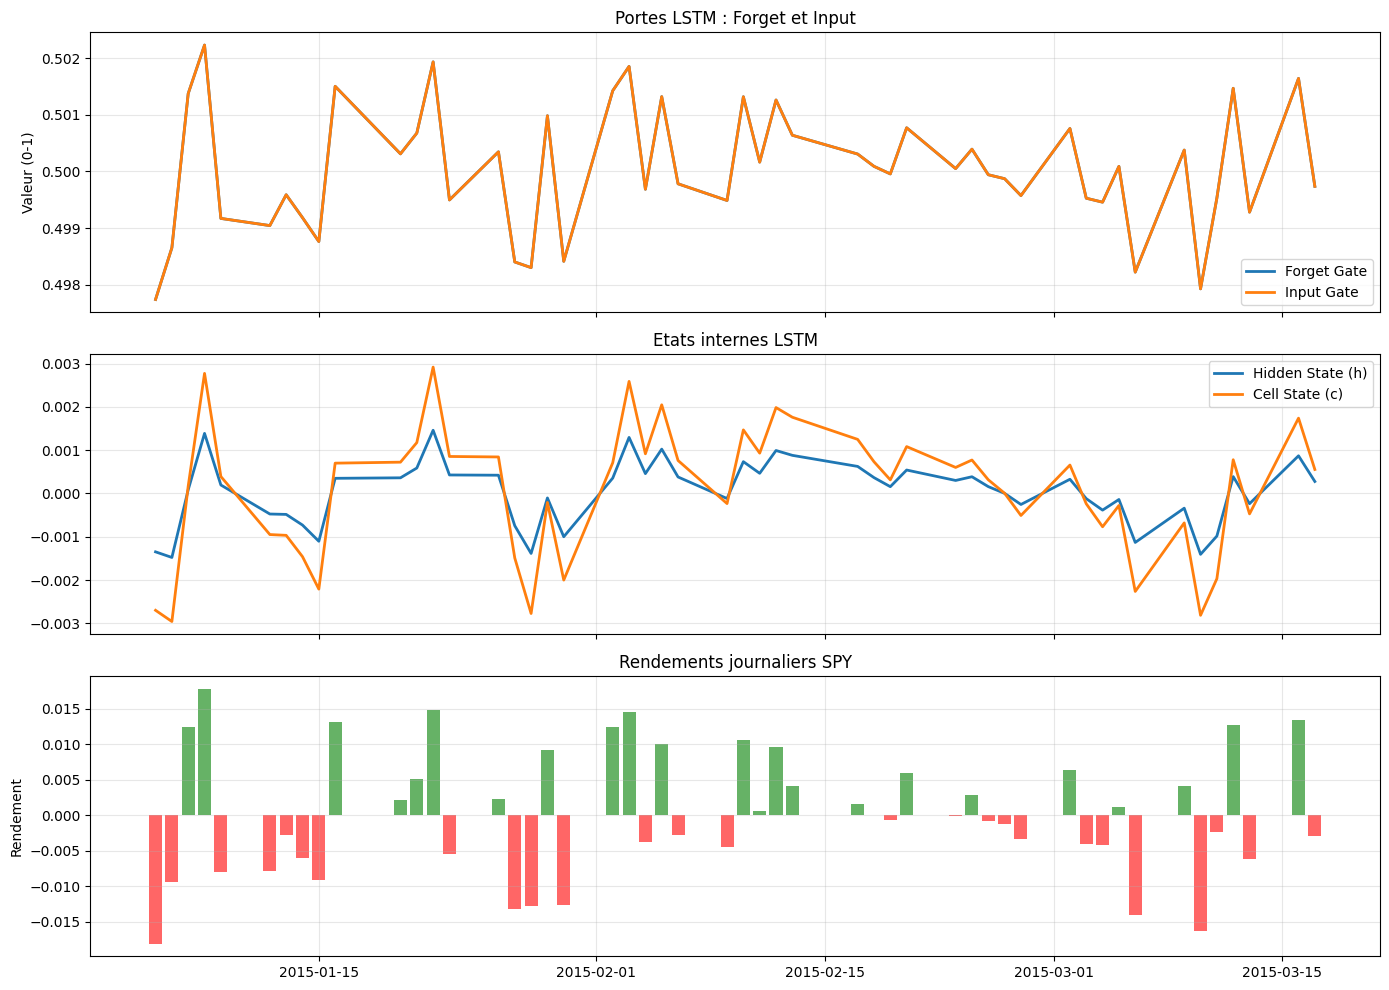

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates_50 = returns.index[:50]

# Portes
axes[0].plot(dates_50, gates_history['forget'], label='Forget Gate', linewidth=2)
axes[0].plot(dates_50, gates_history['input'], label='Input Gate', linewidth=2)
axes[0].set_title('Portes LSTM : Forget et Input')
axes[0].legend()
axes[0].set_ylabel('Valeur (0-1)')

# Etats
axes[1].plot(dates_50, hidden_states, label='Hidden State (h)', linewidth=2)
axes[1].plot(dates_50, cell_states, label='Cell State (c)', linewidth=2)
axes[1].set_title('Etats internes LSTM')
axes[1].legend()

# Rendements originaux
axes[2].bar(dates_50, returns.iloc[:50].values.flatten(), 
            color=['green' if r > 0 else 'red' for r in returns.iloc[:50].values.flatten()],
            alpha=0.6)
axes[2].set_title('Rendements journaliers SPY')
axes[2].set_ylabel('Rendement')

plt.tight_layout()
plt.show()

**Interpretation** : La porte d'oubli controle la quantite de memoire ancienne conservee.
Quand le marche est en tendance, la porte d'entree laisse passer plus d'information.
L'etat cellulaire (c) accumule une memoire a long terme.

## 4. Comparaison LSTM vs RNN simple

In [4]:
def simple_rnn(x_t, h_prev):
    """RNN simple sans portes (reference pour comparaison)."""
    h_new = np.tanh(0.5 * (h_prev + x_t))
    return h_new

# Execution sur toute la serie
seq = returns.values.reshape(-1, 1)

# LSTM
h_lstm = np.array([0.0])
c_lstm = np.array([0.0])
lstm_signals = []

# RNN simple
h_rnn = np.array([0.0])
rnn_signals = []

for t in range(len(seq)):
    h_lstm, c_lstm, _ = lstm_cell(seq[t], h_lstm, c_lstm)
    lstm_signals.append(h_lstm[0])
    
    h_rnn = simple_rnn(seq[t], h_rnn)
    rnn_signals.append(h_rnn[0])

lstm_signals = np.array(lstm_signals)
rnn_signals = np.array(rnn_signals)

print(f"LSTM signal range: [{lstm_signals.min():.4f}, {lstm_signals.max():.4f}]")
print(f"RNN signal range:  [{rnn_signals.min():.4f}, {rnn_signals.max():.4f}]")
print(f"Correlation LSTM-RNN: {np.corrcoef(lstm_signals, rnn_signals)[0,1]:.3f}")

LSTM signal range: [-0.0090, 0.0066]
RNN signal range:  [-0.0591, 0.0433]
Correlation LSTM-RNN: 0.995


## 5. Backtest LSTM simplifie

In [5]:
def backtest_lstm(prices, wf=0.5, wi=0.5, wo=0.5, threshold=0.0):
    """Backtest strategie LSTM simplifiee."""
    returns = prices.pct_change().dropna().values.flatten()
    dates = prices.index[1:]
    
    h = np.array([0.0])
    c = np.array([0.0])
    
    portfolio_value = [1.0]
    
    for i in range(len(returns) - 1):
        x_t = np.array([returns[i]])
        h, c, _ = lstm_cell(x_t, h, c, wf=wf, wi=wi, wo=wo)
        
        position = 1 if h[0] > threshold else 0
        daily_ret = returns[i + 1] * position
        portfolio_value.append(portfolio_value[-1] * (1 + daily_ret))
    
    return pd.Series(portfolio_value[1:], index=dates[1:])

def compute_metrics(pv_series, rf_rate=0.02):
    daily_ret = pv_series.pct_change().dropna()
    n_years = len(daily_ret) / 252
    cagr = (pv_series.iloc[-1] / pv_series.iloc[0]) ** (1 / n_years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (cagr - rf_rate) / ann_vol if ann_vol > 0 else 0
    max_dd = ((pv_series - pv_series.cummax()) / pv_series.cummax()).min()
    return {'CAGR': cagr, 'Volatilite': ann_vol, 'Sharpe': sharpe, 'Max DD': max_dd}

# Test avec differents poids de portes
configs = [
    ('LSTM standard', 0.5, 0.5, 0.5),
    ('LSTM forget+', 0.7, 0.3, 0.5),
    ('LSTM input+', 0.3, 0.7, 0.5),
    ('RNN simple', None, None, None),
]

results = {}
for name, wf, wi, wo in configs:
    if wf is None:
        # RNN simple: utiliser LSTM avec forget=0, input=1
        pv = backtest_lstm(prices, wf=0.0, wi=1.0, wo=1.0)
    else:
        pv = backtest_lstm(prices, wf=wf, wi=wi, wo=wo)
    results[name] = compute_metrics(pv)

# Benchmark
bh = (1 + prices.pct_change().dropna()).cumprod()
results['Buy & Hold'] = compute_metrics(bh)

results_df = pd.DataFrame(results).T
print("=== Resultats du Backtest LSTM vs RNN ===")
for col in ['CAGR', 'Volatilite', 'Max DD']:
    results_df[col] = results_df[col].map('{:.2%}'.format)
for col in ['Sharpe']:
    results_df[col] = results_df[col].map('{:.3f}'.format)
print(results_df)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## 6. Conclusions

### Points cles
- Le LSTM memorise les tendances passees grace a l'etat cellulaire (c)
- La porte d'oubli est le mecanisme cle: elle filtre le bruit vs le signal
- Un forget gate plus eleve (0.7) = memoire plus longue, meilleur en tendance
- Un input gate plus eleve (0.7) = reactivite aux changements recents

### Avantage LSTM vs RNN simple
- Le LSTM evite le gradient evanescent en controlant le flux d'information
- Le RNN simple est plus reactif mais moins stable

### Configuration recommandee pour main.py
- Poids portes: forget=0.5, input=0.5, output=0.5
- Seuil de signal: 0.0
- Etat initial: h=0, c=0